**IMPORTANDO BIBLIOTECAS**

In [1]:
import math             # inclui funções matemáticas como raiz e potência
import pandas as pd     # biblioteca com funções para análise de dados, como carregar dataframes
import numpy as np      # pacote que permite exploração de arrays e manipulação de dados em matrizes
import matplotlib.pyplot as plt
import seaborn as sns   # biblioteca com funções que se integram a pandas e a matplotlib
import scipy
from scipy.stats import variation

**VARIÁVEL COM A PLANILHA DO EXCEL**

pra poder modificar seus dados

In [2]:
arquivo = 'Dados Habitacionais de Ames.xlsx'

**CRIANDO DATAFRAME COM A PLANILHA**

In [3]:
df = pd.read_excel(arquivo)

**DATAFRAME COM ÁREA DO LOTE**

novo dataframe que contem a coluna com a área do lote

In [4]:
df1 = df['Lot Area']

**QUARTIS - ÁREA DO LOTE**

Separar os dados da área do lote em quatro partes iguais

In [5]:
df1.describe().round(2)

,Lot Area
count,2930.00
mean,10147.92
std,7880.02
min,1300.00
25%,7440.25
50%,9436.50
75%,11555.25
max,215245.00


**BOXPLOT - ÁREA DO LOTE**

gráfico que ilustra os dados da área do lote em um boxplot

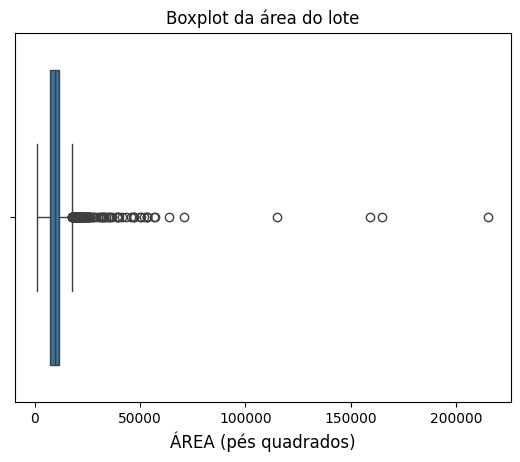

In [6]:
sns.boxplot(data=df1, orient="h")
plt.xlabel('ÁREA (pés quadrados)',fontsize=12)
plt.title('Boxplot da área do lote',fontsize=12)
plt.show()

**BOXPLOT SEM OS OUTLIERS**

O gráfico visualizado de forma a não exibir os outliers, primeiro definimos o primeiro e o terceiro quartis

In [7]:
Q1 = df1.quantile(0.25)
Q3 = df1.quantile(0.75)

Amplitude interquartil: a diferença entre o Q3 e o Q1

In [8]:
AIQ = Q3 - Q1

Terceiro, calcule os limites (linf = Q1 - 1.5*AIQ e lsup = Q3 + 1.5*AIQ)

In [9]:
l_inf = Q1 - 1.5*AIQ
l_sup = Q3 + 1.5*AIQ
print("limite inferior =", l_inf)
print("limite superior =", l_sup)

limite inferior = 1267.75
limite superior = 17727.75


**LISTANDO OUTLIERS INFERIORES E SUPERIORES**

Limites inferiores:

In [10]:
df[df1 < l_inf]  # não tem

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice


Limites superiores:

In [11]:
df[df1 > l_sup]

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
15,16,527216070,60,RL,47.0,53504,Pave,NaN,IR2,HLS,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,538000
18,19,527276150,20,RL,140.0,19138,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,141000
51,52,528218150,20,RL,100.0,18494,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,199500
113,114,534152070,50,RL,NaN,18837,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,212500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2885,2886,913350030,20,RL,69.0,23580,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,9,2006,WD,Normal,242500
2891,2892,916225130,60,RL,42.0,26178,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,335000
2893,2894,916325040,20,RL,NaN,50102,Pave,NaN,IR1,Low,...,0,NaN,NaN,NaN,0,3,2006,WD,Alloca,250764
2903,2904,923125030,20,A (agr),125.0,31250,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,5,2006,WD,Normal,81500


**ELIMINANDO OUTLIERS DO DATAFRAME**

Usando comando para retirar os outliers do boxplot e do dataframe

In [12]:
df1_small = df1[(df1 >= l_inf) & (df1 <= l_sup)]
df1_small

,Lot Area
1,11622
2,14267
3,11160
4,13830
5,9978
...,...
2925,7937
2926,8885
2927,10441
2928,10010


**BOXPLOT SEM OUTLIERS**

utilizando novo dataframe com dados tratados

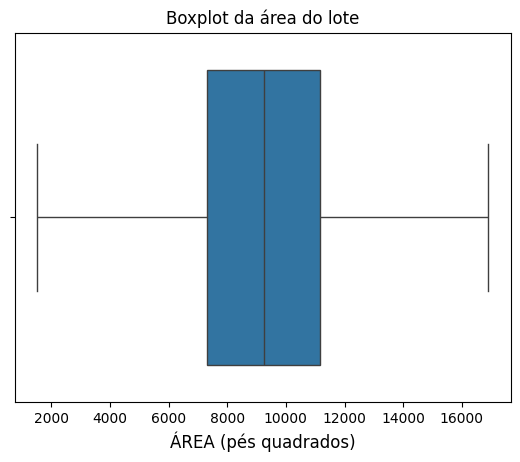

In [ ]:
sns.boxplot(data=df1_small, orient="h", showfliers = False)
plt.xlabel('ÁREA (pés quadrados)',fontsize=12)
plt.title('Boxplot da área do lote',fontsize=12)
plt.show()

**BOXPLOT COMPARATIVO**

Ultilizando as Variaveis: Preço de Venda e Bairro para a Comparação

/tmp/ipykernel_562/4024689329.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


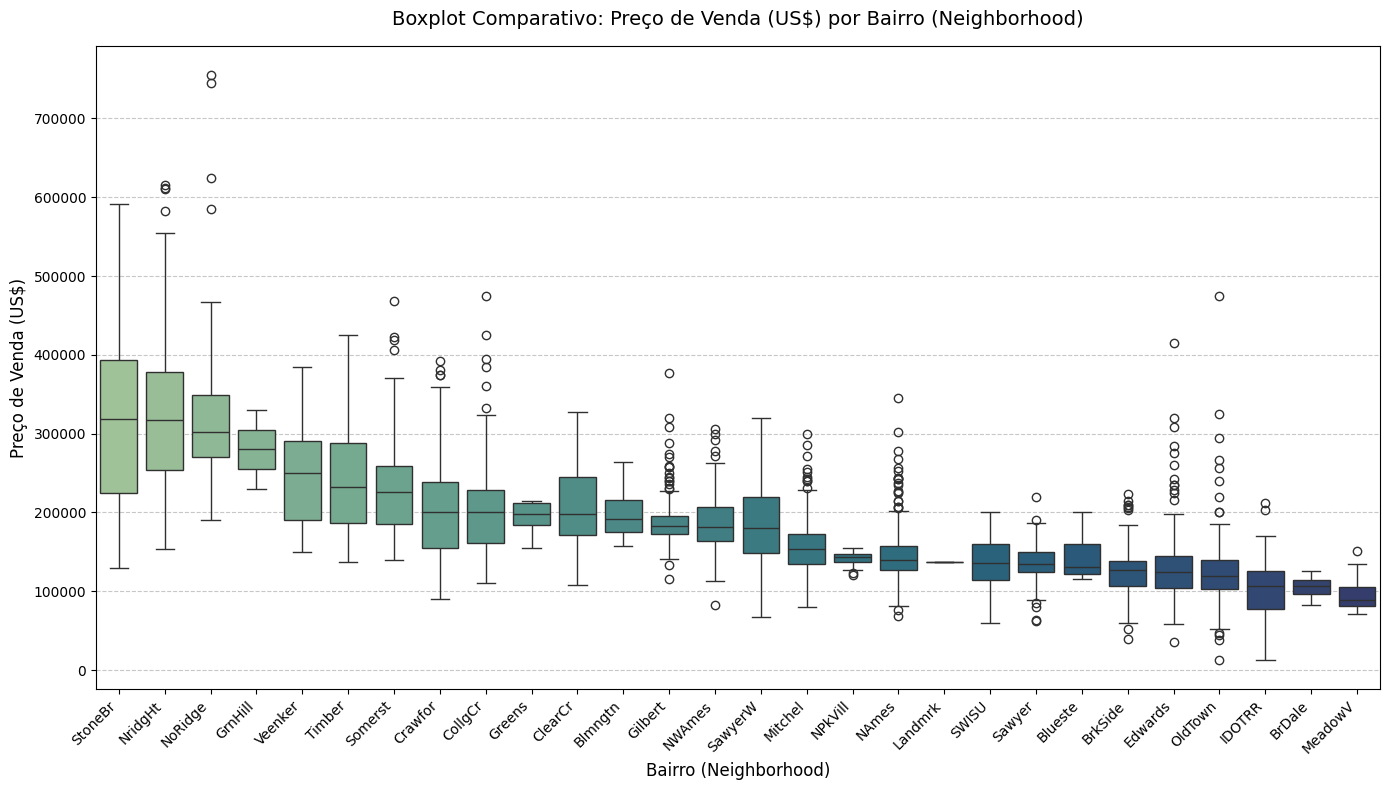

In [28]:
plt.figure(figsize=(14, 8))

ordem_bairros = (
    df.groupby('Neighborhood')['SalePrice']
    .median()
    .sort_values(ascending=False)
    .index
)

sns.boxplot(
    data=df,
    x='Neighborhood',
    y='SalePrice',
    order=ordem_bairros,
    palette='crest',

)
plt.title(
    'Boxplot Comparativo: Preço de Venda (US$) por Bairro (Neighborhood)',
    fontsize=14,
    pad=15,
)
plt.xlabel('Bairro (Neighborhood)', fontsize=12)
plt.ylabel('Preço de Venda (US$)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**DESVIO PADRÃO DA ÁREA DO LOTE**

calcular e definir quanto que os dados se dispersam do centro

**Desvio Padrão Amostral**

In [ ]:
df1.std()

7880.017759439081

**Desvio Padrão Populacional**

In [ ]:
df1.std(ddof=0)

7878.672931754667

**COEFICIENTE DE VARIAÇÃO**

**Coeficiente de Varição Amostral**

Cálculo do Coeficiente de Variação Amostral usando a biblioteca scipy

In [ ]:
scipy.stats.variation(df1,ddof = 1) * 100

np.float64(77.65154167867433)

**Coeficiente de Variação Populacional**

Cálculo do Coeficiente de Variação Populacional usando a Biblioteca Scipy

In [ ]:
scipy.stats.variation(df1,ddof=0)*100

np.float64(77.6382894315126)